<a href="https://colab.research.google.com/github/phhien203/ML-foundations/blob/master/TSLA_Forecast_Evaluation_Hien.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
%pip install yfinance pandas numpy matplotlib scikit-learn xgboost

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

from sklearn.pipeline import make_pipeline

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.float_format', lambda x: '%.4f' % x)


In [15]:
START_DATE = '2016-10-08'
END_DATE = '2026-10-08'

ticker = 'TSLA'

df = yf.download(
    ticker,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

if isinstance(df.columns, pd.MultiIndex):
  df = df.xs('TSLA', axis=1, level=1)

df = df.sort_index()

print('First date:', df.index.min())
print('Last date:', df.index.max())
print('Number of rows:', len(df))

print(df.isna().sum())

print(df.shape)
display(df.head())
display(df.tail())

First date: 2016-10-10 00:00:00
Last date: 2026-10-07 00:00:00
Number of rows: 2512
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
(2512, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2016-10-10,13.3967,13.6093,13.3107,13.4233,49744500
2016-10-11,13.3400,13.4800,13.2207,13.4567,34926000
2016-10-12,13.4340,13.5920,13.3613,13.3967,29560500
2016-10-13,13.3493,13.3933,13.1367,13.3667,37419000
2016-10-14,13.1007,13.4287,13.0867,13.3773,64048500


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-10-01,354.1100,359.7900,353.8000,356.8100,31080800
2026-10-02,370.5900,374.6000,359.4100,360.0800,55330100
2026-10-05,378.7300,381.5900,364.9100,369.0000,42232700
2026-10-06,380.6800,383.3300,378.5200,381.9800,27735400
2026-10-07,377.8100,382.3500,374.4300,378.4500,25594600


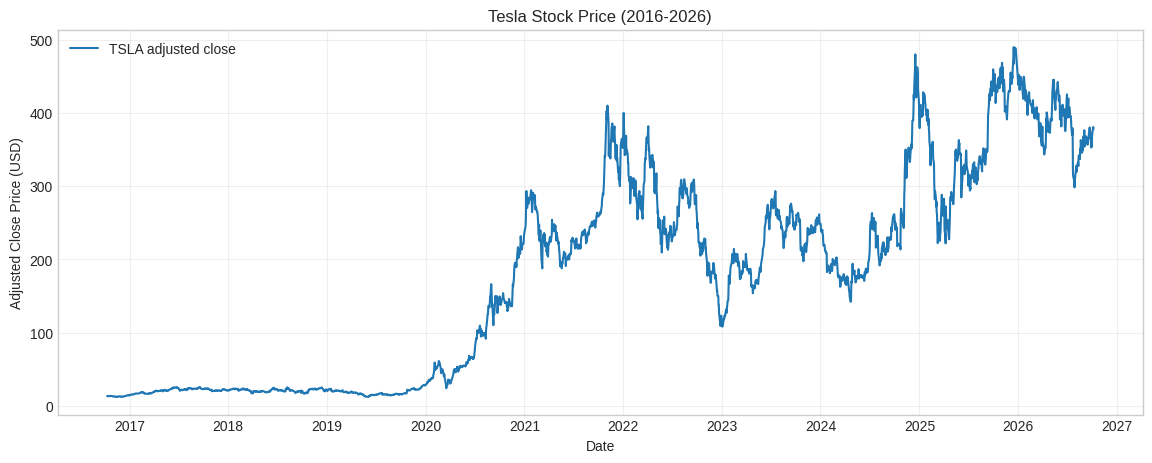

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df['Close'],
    label='TSLA adjusted close'
)

plt.title('Tesla Stock Price (2016-2026)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [17]:
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

df['target'] = df['log_return'].shift(-1)
df['return_today'] = df['log_return']

df.head()

Price,Close,High,Low,Open,Volume,log_return,target,return_today
Date,,,,,,,,
2016-10-10,13.3967,13.6093,13.3107,13.4233,49744500,NaN,-0.0042,NaN
2016-10-11,13.3400,13.4800,13.2207,13.4567,34926000,-0.0042,0.0070,-0.0042
2016-10-12,13.4340,13.5920,13.3613,13.3967,29560500,0.0070,-0.0063,0.0070
2016-10-13,13.3493,13.3933,13.1367,13.3667,37419000,-0.0063,-0.0188,-0.0063
2016-10-14,13.1007,13.4287,13.0867,13.3773,64048500,-0.0188,-0.0131,-0.0188


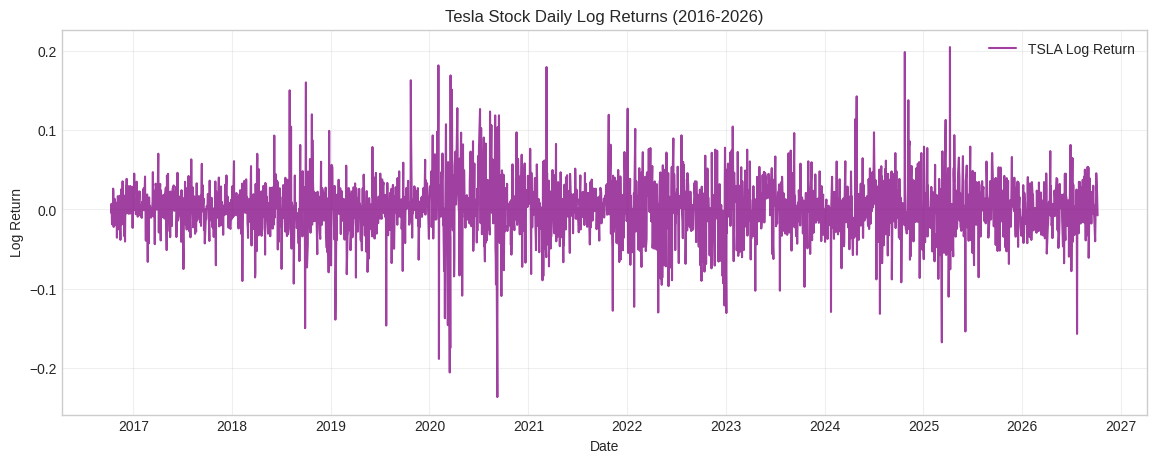

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(
    df.index,
    df['log_return'],
    label='TSLA Log Return',
    color='purple',
    alpha=0.75
)
plt.title('Tesla Stock Daily Log Returns (2016-2026)')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
df['lag_1'] = df['log_return'].shift(1)
df['lag_2'] = df['log_return'].shift(2)
df['lag_5'] = df['log_return'].shift(5)

df.head(10)

Price,Close,High,Low,Open,Volume,log_return,target,return_today,lag_1,lag_2,lag_5
Date,,,,,,,,,,,
2016-10-10,13.3967,13.6093,13.3107,13.4233,49744500,NaN,-0.0042,NaN,NaN,NaN,NaN
2016-10-11,13.3400,13.4800,13.2207,13.4567,34926000,-0.0042,0.0070,-0.0042,NaN,NaN,NaN
2016-10-12,13.4340,13.5920,13.3613,13.3967,29560500,0.0070,-0.0063,0.0070,-0.0042,NaN,NaN
2016-10-13,13.3493,13.3933,13.1367,13.3667,37419000,-0.0063,-0.0188,-0.0063,0.0070,-0.0042,NaN
2016-10-14,13.1007,13.4287,13.0867,13.3773,64048500,-0.0188,-0.0131,-0.0188,-0.0063,0.0070,NaN
2016-10-17,12.9307,13.2260,12.8000,13.1367,68311500,-0.0131,0.0262,-0.0131,-0.0188,-0.0063,NaN
2016-10-18,13.2733,13.2980,12.8840,13.0660,85207500,0.0262,0.0222,0.0262,-0.0131,-0.0188,-0.0042
2016-10-19,13.5707,13.7773,13.2040,13.3160,104868000,0.0222,-0.0222,0.0222,0.0262,-0.0131,0.0070
2016-10-20,13.2733,13.5333,13.1367,13.4747,76093500,-0.0222,0.0050,-0.0222,0.0222,0.0262,-0.0063


In [20]:
df['volatility_5'] = df['log_return'].rolling(window=5).std()
df['volatility_20'] = df['log_return'].rolling(window=20).std()

df.tail(20)

Price,Close,High,Low,Open,Volume,log_return,target,return_today,lag_1,lag_2,lag_5,volatility_5,volatility_20
Date,,,,,,,,,,,,,
2026-09-10,363.5600,369.2100,357.6800,360.6000,29667200,-0.0116,0.0052,-0.0116,-0.0010,0.0390,0.0026,0.0450,0.0327
2026-09-11,365.4400,368.6600,361.6000,364.2000,30153000,0.0052,-0.0179,0.0052,-0.0116,-0.0010,0.0528,0.0362,0.0318
2026-09-14,358.9700,367.7300,357.0400,359.7800,32477200,-0.0179,-0.0067,-0.0179,0.0052,-0.0116,-0.0610,0.0222,0.0322
2026-09-15,356.5800,362.3900,354.0500,358.7500,30317700,-0.0067,0.0042,-0.0067,-0.0179,0.0052,0.0390,0.0090,0.0321
2026-09-16,358.0800,365.1000,354.8900,357.9300,32177400,0.0042,0.0224,0.0042,-0.0067,-0.0179,-0.0010,0.0100,0.0321
2026-09-17,366.2000,374.1200,363.2200,367.4800,38924100,0.0224,-0.0053,0.0224,0.0042,-0.0067,-0.0116,0.0150,0.0311
2026-09-18,364.2700,370.9000,360.7500,369.0000,51922300,-0.0053,0.0298,-0.0053,0.0224,0.0042,0.0052,0.0151,0.0309
2026-09-21,375.3000,378.3600,371.0700,371.6400,36599600,0.0298,0.0095,0.0298,-0.0053,0.0224,-0.0179,0.0165,0.0295
2026-09-22,378.9000,380.4200,372.8800,379.0700,28229900,0.0095,0.0032,0.0095,0.0298,-0.0053,-0.0067,0.0141,0.0279


In [21]:
df['momentum_5'] = df['log_return'].rolling(window=5).sum()
df['momentum_20'] = df['log_return'].rolling(window=20).sum()
df['ma_20'] = df['Close'].rolling(window=20).mean()
df['distance_ma20'] = df['Close'] / df['ma_20'] - 1
df['day_of_week'] = df.index.dayofweek

df.tail()

Price,Close,High,Low,Open,Volume,log_return,target,return_today,lag_1,lag_2,lag_5,volatility_5,volatility_20,momentum_5,momentum_20,ma_20,distance_ma20,day_of_week
Date,,,,,,,,,,,,,,,,,,
2026-10-01,354.1100,359.7900,353.8000,356.8100,31080800,-0.0020,0.0455,-0.0020,0.0056,-0.0130,-0.0058,0.0174,0.0253,-0.0651,-0.0082,365.1550,-0.0302,3
2026-10-02,370.5900,374.6000,359.4100,360.0800,55330100,0.0455,0.0217,0.0455,-0.0020,0.0056,-0.0155,0.0312,0.0246,-0.0041,-0.0155,364.8660,0.0157,4
2026-10-05,378.7300,381.5900,364.9100,369.0000,42232700,0.0217,0.0051,0.0217,0.0455,-0.0020,-0.0402,0.0228,0.0205,0.0578,0.0673,366.0985,0.0345,0
2026-10-06,380.6800,383.3300,378.5200,381.9800,27735400,0.0051,-0.0076,0.0051,0.0217,0.0455,-0.0130,0.0190,0.0187,0.0759,0.0334,366.7245,0.0381,1
2026-10-07,377.8100,382.3500,374.4300,378.4500,25594600,-0.0076,NaN,-0.0076,0.0051,0.0217,0.0056,0.0214,0.0188,0.0628,0.0268,367.2245,0.0288,2


In [22]:
feature_columns = [
    'return_today',
    'lag_1',
    'lag_2',
    'lag_5',
    'volatility_5',
    'volatility_20',
    'momentum_5',
    'momentum_20',
    'distance_ma20',
    'day_of_week'
]

data = df.dropna(subset=feature_columns + ['target']).copy()

X = data[feature_columns]
y = data['target']

print('Features:', X.shape)
print('Target:', y.shape)

display(X.tail())

Features: (2491, 10)
Target: (2491,)


Price,return_today,lag_1,lag_2,lag_5,volatility_5,volatility_20,momentum_5,momentum_20,distance_ma20,day_of_week
Date,,,,,,,,,,
2026-09-30,0.0056,-0.0130,-0.0402,0.0032,0.0169,0.0253,-0.0689,-0.0036,-0.0287,2
2026-10-01,-0.0020,0.0056,-0.0130,-0.0058,0.0174,0.0253,-0.0651,-0.0082,-0.0302,3
2026-10-02,0.0455,-0.0020,0.0056,-0.0155,0.0312,0.0246,-0.0041,-0.0155,0.0157,4
2026-10-05,0.0217,0.0455,-0.0020,-0.0402,0.0228,0.0205,0.0578,0.0673,0.0345,0
2026-10-06,0.0051,0.0217,0.0455,-0.0130,0.0190,0.0187,0.0759,0.0334,0.0381,1


In [23]:
tscv = TimeSeriesSplit(
    n_splits=6,
    test_size=250,
    gap=1
)

In [24]:
# fig, axes = plt.subplots(tscv.n_splits, 2, figsize=(16, 2 * tscv.n_splits), sharex=True, constrained_layout=True)

results = []
predictions = []
fold_periods = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
  # ------------------------------
  # 1. Split the train, test
  # ------------------------------
  X_train = X.iloc[train_idx]
  X_test = X.iloc[test_idx]

  y_train = y.iloc[train_idx]
  y_test = y.iloc[test_idx]

  fold_periods.append({
      'fold': fold,
      'train_start': X_train.index.min(),
      'train_end': X_train.index.max(),
      'test_start': X_test.index.min(),
      'test_end': X_test.index.max()
  })

  # ------------------------------
  # 2. Target scaling
  # ------------------------------
  target_mu = y_train.mean()
  target_std = y_train.std()

  if target_std <= 0:
    raise ValueError('Target std must be positive')

  y_train_scaled = (y_train - target_mu) / target_std

  # ------------------------------
  # 3. Create models
  # ------------------------------
  models = {
      'Ridge': make_pipeline(
          StandardScaler(),
          Ridge(alpha=10.0)
      ),
      'XGBoost': XGBRegressor(
          n_estimators=200,
          learning_rate=0.02,
          max_depth=3,
          min_child_weight=20,
          subsample=0.8,
          colsample_bytree=0.8,
          reg_lambda=5.0,
          # early_stopping_rounds=100,
          random_state=42
      )
  }

  # ------------------------------
  # 4. Naive baseline
  # ------------------------------
  naive_return_pred = np.zeros(len(y_test))

  # ------------------------------
  # 5. Train and predict
  # ------------------------------
  return_predictions = {
      'Naive': naive_return_pred
  }

  for name, model in models.items():
    model.fit(
        X_train,
        y_train_scaled
    )

    scaled_pred = model.predict(X_test)

    # Inverse target scaling
    return_pred = scaled_pred * target_std + target_mu

    return_predictions[name] = return_pred

  # ------------------------------
  # 6. Convert return to price
  # ------------------------------
  current_price = data.loc[X_test.index, 'Close'].to_numpy()

  actual_return = y_test.to_numpy()

  actual_price = current_price * np.exp(actual_return)

  naive_price = current_price * np.exp(naive_return_pred)

  naive_mea = mean_absolute_error(actual_price, naive_price)

  # ------------------------------
  # 7. Evaluate every model
  # ------------------------------
  for name, return_pred in return_predictions.items():
    predicted_price = current_price * np.exp(return_pred)
    mae = mean_absolute_error(actual_price, predicted_price)
    rmse = np.sqrt(
        mean_squared_error(actual_price, predicted_price)
    )
    mape = np.mean(np.abs((actual_price - predicted_price) / actual_price)) * 100

    mae_ratio = mae / naive_mea

    results.append({
        'fold': fold,
        'model': name,
        'MAE_USD': mae,
        'RMSE_USD': rmse,
        'MAPE_pct': mape,
        'MAE_div_naive': mae_ratio
    })

    # Daily predictions for figures
    fold_predictions = pd.DataFrame({
        'fold': fold,
        'model': name,
        'current_price': current_price,
        'actual_price': actual_price,
        'predicted_price': predicted_price,
        'actual_return': actual_return,
        'predicted_return': return_pred
    }, index=X_test.index)

    predictions.append(fold_predictions)

  print(f'Fold {fold} completed')

  # print(f'Fold {fold}')
  # print(
  #     'Train:',
  #     X_train.index.min().date(),
  #     '->',
  #     X_train.index.max().date()
  # )

  # print(
  #     'Test:',
  #     X_test.index.min().date(),
  #     '->',
  #     X_test.index.max().date()
  # )

  # # Plot figure 1
  # train_dates = X.index[train_idx]
  # test_dates = X.index[test_idx]

  # # Get corresponding Series from data
  # y_train_close = data.loc[train_dates, 'Close']
  # y_test_close = data.loc[test_dates, 'Close']

  # y_train_log = data.loc[train_dates, 'log_return']
  # y_test_log = data.loc[test_dates, 'log_return']

  # row = fold - 1

  # # Plot Close Price
  # axes[row, 0].plot(train_dates, y_train_close, color='blue', label='Train' if row == 0 else "")
  # axes[row, 0].plot(test_dates, y_test_close, color='orange', label='Test' if row == 0 else "")
  # axes[row, 0].set_ylabel(f'Fold {fold}\nClose Price')
  # if row == 0:
  #     axes[row, 0].set_title('Close Price splits')
  #     axes[row, 0].legend(loc='upper left')
  # axes[row, 0].grid(True, alpha=0.3)

  # # Plot Log Return
  # axes[row, 1].plot(train_dates, y_train_log, color='blue')
  # axes[row, 1].plot(test_dates, y_test_log, color='orange')
  # axes[row, 1].set_ylabel('Log Return')
  # if row == 0:
  #     axes[row, 1].set_title('Log Return splits')
  # axes[row, 1].grid(True, alpha=0.3)

# plt.xlabel('Date')
# plt.show()

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
Fold 6 completed


In [25]:
results_df = pd.DataFrame(results)

display(results_df.sort_values(['fold', 'model']).round(4))

,fold,model,MAE_USD,RMSE_USD,MAPE_pct,MAE_div_naive
0,1,Naive,5.3250,7.3294,2.4174,1.0000
1,1,Ridge,5.3553,7.3427,2.4350,1.0057
2,1,XGBoost,5.3460,7.4441,2.4300,1.0039
3,2,Naive,9.4080,12.5084,3.1656,1.0000
4,2,Ridge,9.4578,12.6603,3.1879,1.0053
5,2,XGBoost,9.4334,12.5000,3.1744,1.0027
6,3,Naive,5.5850,7.3652,2.8236,1.0000
7,3,Ridge,5.5574,7.3742,2.8155,0.9951
8,3,XGBoost,5.5555,7.3232,2.8167,0.9947
9,4,Naive,5.2897,7.2043,2.5500,1.0000


In [26]:
summary_df = results_df.groupby('model').agg(
    MAE_mean=('MAE_USD', 'mean'),
    MAE_std=('MAE_USD', 'std'),

    RMSE_mean=('RMSE_USD', 'mean'),
    RMSE_std=('RMSE_USD', 'std'),

    MAPE_mean=('MAPE_pct', 'mean'),
    MAPE_std=('MAPE_pct', 'std'),

    Ratio_mean=('MAE_div_naive', 'mean'),
    Ratio_std=('MAE_div_naive', 'std')
)

display(summary_df.round(4))

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPE_mean,MAPE_std,Ratio_mean,Ratio_std
model,,,,,,,,
Naive,7.4486,2.2968,9.9334,2.9744,2.7219,0.4023,1.0000,0.0000
Ridge,7.4710,2.3265,9.9732,3.0007,2.7336,0.4120,1.0023,0.0052
XGBoost,7.4606,2.3014,9.9436,2.9648,2.7288,0.3935,1.0015,0.0049


In [27]:
metrics = [
    "MAE_USD",
    "RMSE_USD",
    "MAPE_pct",
    "MAE_div_naive"
]

summary_report = pd.DataFrame()

for metric in metrics:

    grouped = results_df.groupby("model")[metric]

    mean = grouped.mean()
    std = grouped.std()

    summary_report[metric] = [
        f"{mean.loc[m]:.4f} ± {std.loc[m]:.4f}"
        for m in mean.index
    ]

display(summary_report)

,MAE_USD,RMSE_USD,MAPE_pct,MAE_div_naive
0,7.4486 ± 2.2968,9.9334 ± 2.9744,2.7219 ± 0.4023,1.0000 ± 0.0000
1,7.4710 ± 2.3265,9.9732 ± 3.0007,2.7336 ± 0.4120,1.0023 ± 0.0052
2,7.4606 ± 2.3014,9.9436 ± 2.9648,2.7288 ± 0.3935,1.0015 ± 0.0049


In [28]:
ratio_table = results_df.pivot(
    index="fold",
    columns="model",
    values="MAE_div_naive"
)

display(ratio_table.round(4))

print(
    "Ridge wins:",
    (ratio_table["Ridge"] < 1).sum(),
    "out of 6 folds"
)

print(
    "XGBoost wins:",
    (ratio_table["XGBoost"] < 1).sum(),
    "out of 6 folds"
)

model,Naive,Ridge,XGBoost
fold,,,
1,1.0000,1.0057,1.0039
2,1.0000,1.0053,1.0027
3,1.0000,0.9951,0.9947
4,1.0000,0.9997,1.0022
5,1.0000,1.0090,0.9972
6,1.0000,0.9989,1.0082


Ridge wins: 3 out of 6 folds
XGBoost wins: 2 out of 6 folds


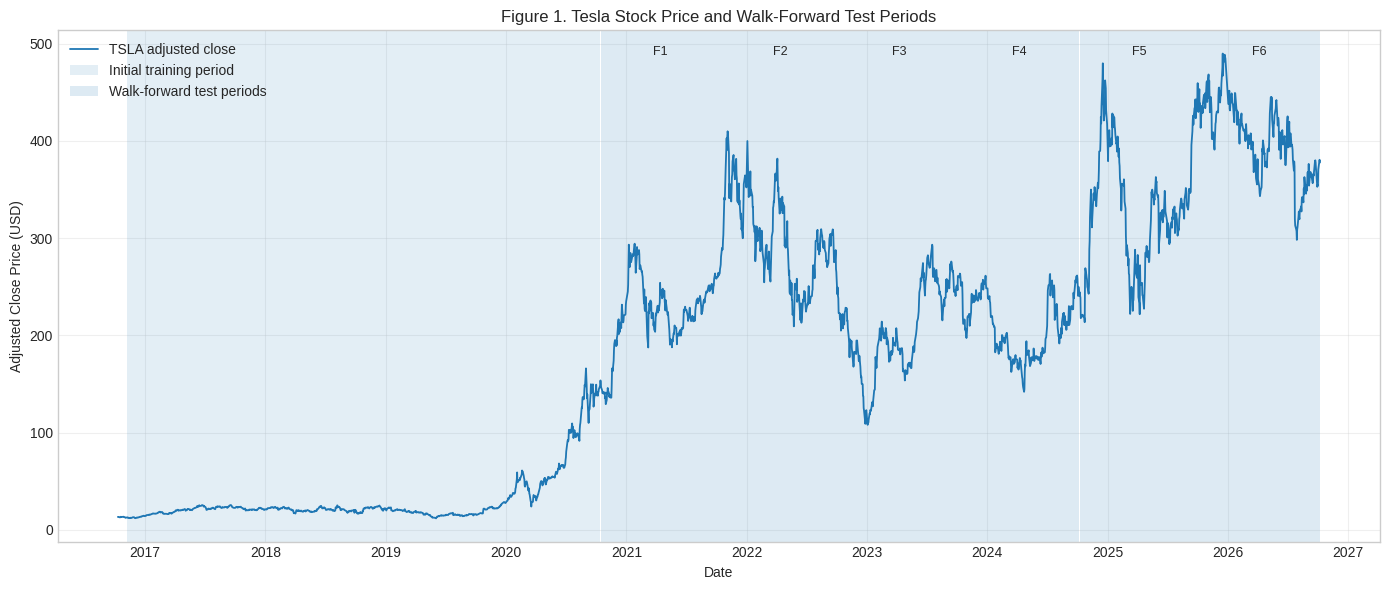

In [29]:
folds_df = pd.DataFrame(fold_periods)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df.index,
    df["Close"],
    label="TSLA adjusted close",
    linewidth=1.3
)

# Show the first training period
first_fold = folds_df.iloc[0]

ax.axvspan(
    first_fold["train_start"],
    first_fold["train_end"],
    alpha=0.12,
    label="Initial training period"
)

# Show all six test periods
for i, row in folds_df.iterrows():

    ax.axvspan(
        row["test_start"],
        row["test_end"],
        alpha=0.15,
        label="Walk-forward test periods" if i == 0 else None
    )

    midpoint = (
        row["test_start"]
        + (row["test_end"] - row["test_start"]) / 2
    )

    ax.text(
        midpoint,
        ax.get_ylim()[1] * 0.95,
        f"F{int(row['fold'])}",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Figure 1. Tesla Stock Price and Walk-Forward Test Periods"
)

ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price (USD)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figure1_data_splits.png", dpi=200)
plt.show()

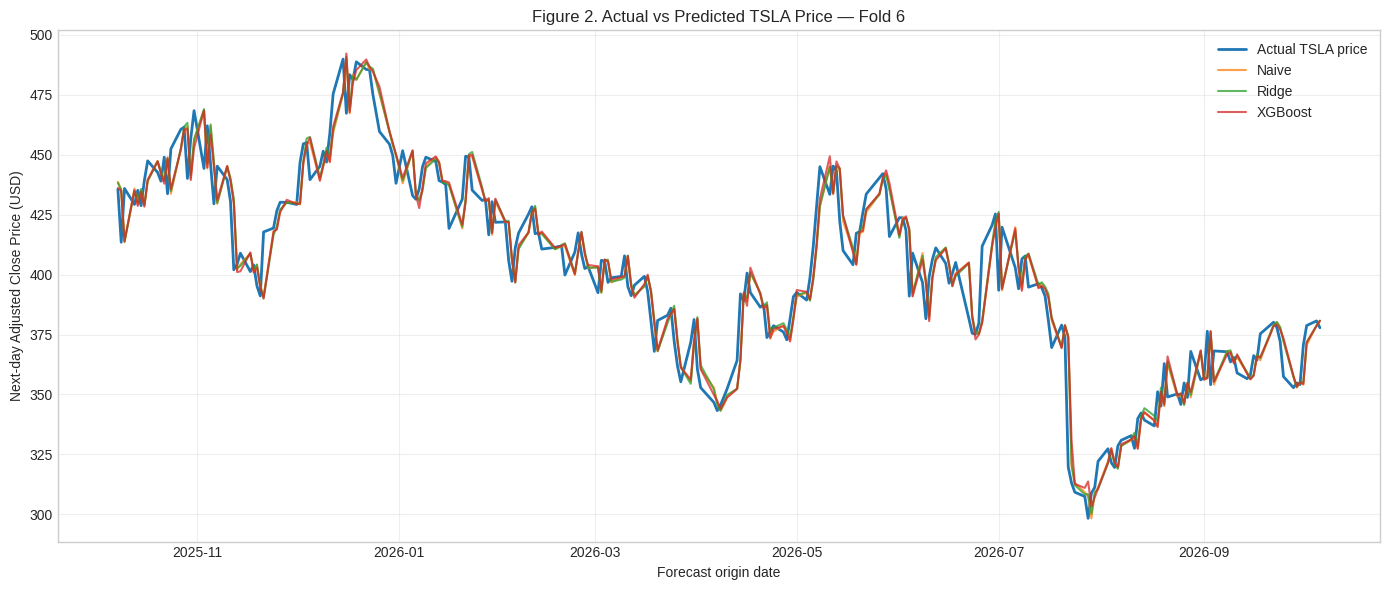

In [30]:
predictions_df = pd.concat(
    predictions
).sort_index()

fold_6 = predictions_df[
    predictions_df["fold"] == 6
]

actual = (
    fold_6[fold_6["model"] == "Naive"]
    ["actual_price"]
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    actual.index,
    actual.values,
    label="Actual TSLA price",
    linewidth=2
)

for model_name in ["Naive", "Ridge", "XGBoost"]:

    model_data = fold_6[
        fold_6["model"] == model_name
    ]

    ax.plot(
        model_data.index,
        model_data["predicted_price"],
        label=model_name,
        alpha=0.75
    )

ax.set_title(
    "Figure 2. Actual vs Predicted TSLA Price — Fold 6"
)

ax.set_xlabel("Forecast origin date")
ax.set_ylabel("Next-day Adjusted Close Price (USD)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figure2_forecast_vs_actual.png", dpi=200)
plt.show()

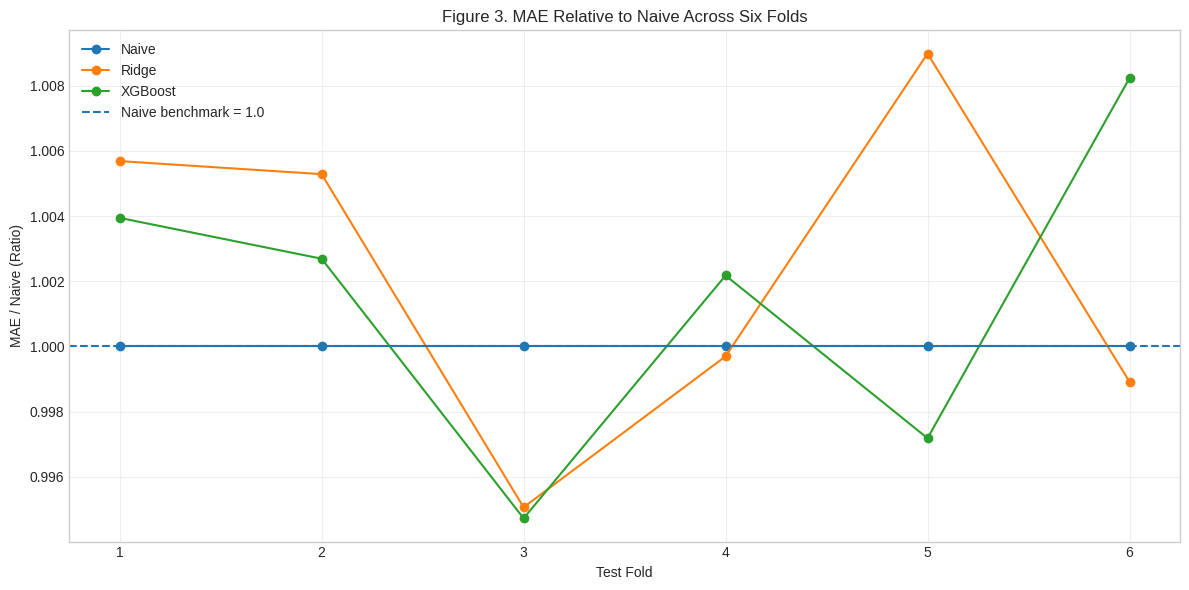

In [31]:
ratio_table = results_df.pivot(
    index="fold",
    columns="model",
    values="MAE_div_naive"
)

fig, ax = plt.subplots(figsize=(12, 6))

for model_name in ["Naive", "Ridge", "XGBoost"]:

    ax.plot(
        ratio_table.index,
        ratio_table[model_name],
        marker="o",
        label=model_name
    )

ax.axhline(
    y=1,
    linestyle="--",
    label="Naive benchmark = 1.0"
)

ax.set_title(
    "Figure 3. MAE Relative to Naive Across Six Folds"
)

ax.set_xlabel("Test Fold")
ax.set_ylabel("MAE / Naive (Ratio)")
ax.set_xticks(range(1, 7))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figure3_mae_ratio_per_fold.png", dpi=200)
plt.show()

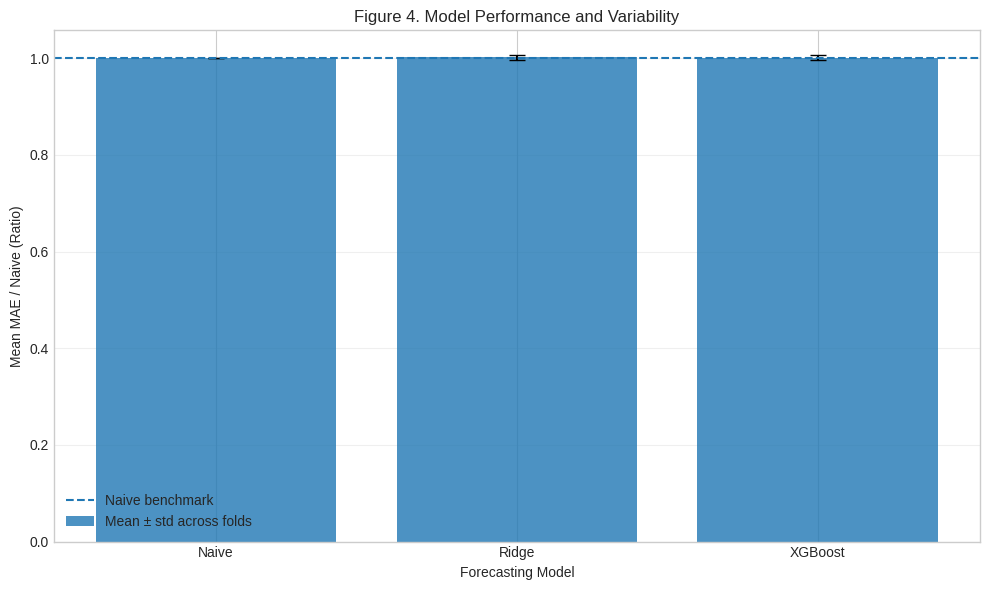

In [32]:
model_summary = (
    results_df
    .groupby("model")["MAE_div_naive"]
    .agg(["mean", "std"])
)

model_order = ["Naive", "Ridge", "XGBoost"]

model_summary = model_summary.loc[model_order]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    model_summary.index,
    model_summary["mean"],
    yerr=model_summary["std"].fillna(0),
    capsize=6,
    alpha=0.8,
    label="Mean ± std across folds"
)

ax.axhline(
    1,
    linestyle="--",
    label="Naive benchmark"
)

ax.set_title(
    "Figure 4. Model Performance and Variability"
)

ax.set_xlabel("Forecasting Model")
ax.set_ylabel("Mean MAE / Naive (Ratio)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figure4_model_comparison.png", dpi=200)
plt.show()

In [33]:
direction_results = []

for fold in range(1, 7):

    fold_data = predictions_df[
        predictions_df["fold"] == fold
    ]

    actual_returns = (
        fold_data[fold_data["model"] == "Naive"]
        ["actual_return"]
        .to_numpy()
    )

    # Always-up baseline
    always_up_accuracy = (
        actual_returns > 0
    ).mean()

    for model_name in ["Ridge", "XGBoost"]:

        model_data = fold_data[
            fold_data["model"] == model_name
        ]

        predicted_returns = (
            model_data["predicted_return"]
            .to_numpy()
        )

        directional_accuracy = (
            (predicted_returns > 0)
            == (actual_returns > 0)
        ).mean()

        direction_results.append({
            "fold": fold,
            "model": model_name,
            "directional_accuracy": directional_accuracy,
            "always_up_accuracy": always_up_accuracy
        })

direction_df = pd.DataFrame(direction_results)

display(direction_df.round(4))

,fold,model,directional_accuracy,always_up_accuracy
0,1,Ridge,0.5120,0.5400
1,1,XGBoost,0.5400,0.5400
2,2,Ridge,0.5560,0.5120
3,2,XGBoost,0.5240,0.5120
4,3,Ridge,0.5240,0.5240
5,3,XGBoost,0.4840,0.5240
6,4,Ridge,0.5320,0.5200
7,4,XGBoost,0.5040,0.5200
8,5,Ridge,0.4680,0.5000
9,5,XGBoost,0.5280,0.5000
